In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score
import pandas as pd

In [3]:
df = pd.read_csv('diabetes1.csv')

In [4]:
df.shape

(253680, 22)

In [5]:
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


C:\Users\lahir\AppData\Local\Temp\ipykernel_23392\639456042.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Diabetes_binary', data=df, ax=axes[0], palette='Set2')


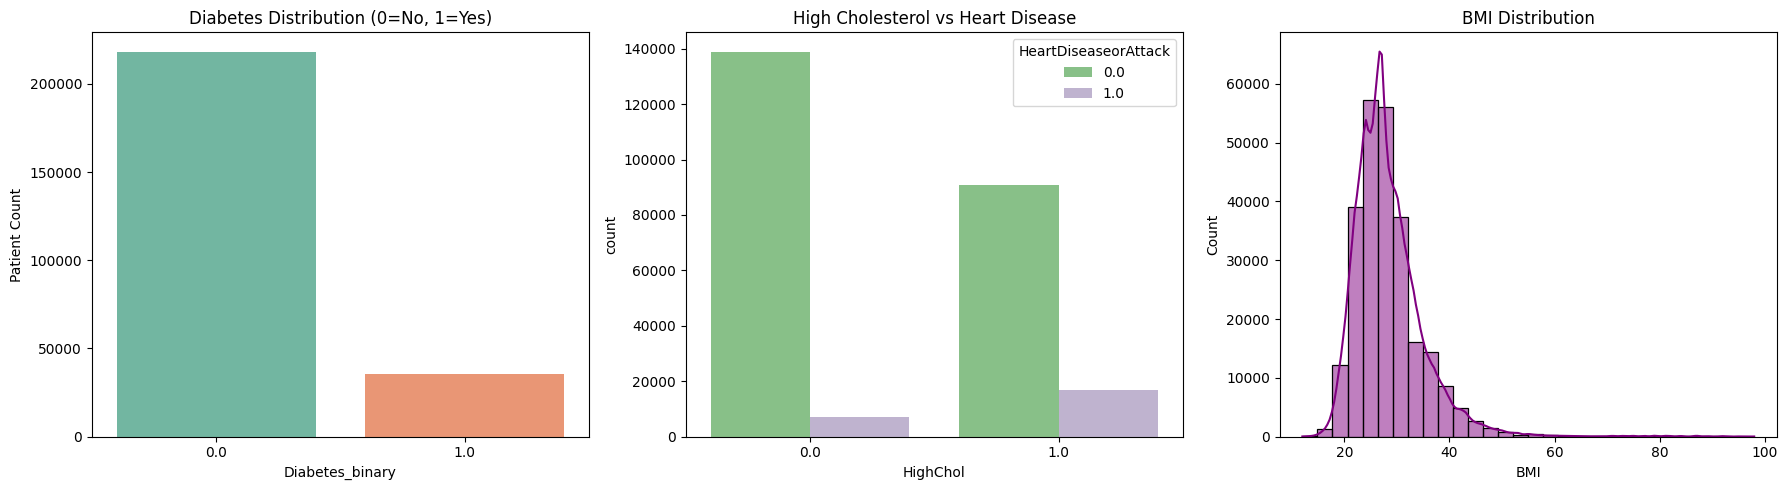

In [6]:
# create 3 Subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Graph 1: Diabetes 
sns.countplot(x='Diabetes_binary', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Diabetes Distribution (0=No, 1=Yes)')
axes[0].set_ylabel('Patient Count')

# Graph 2: High Cholesterol and Heart Disease
sns.countplot(x='HighChol', hue='HeartDiseaseorAttack', data=df, ax=axes[1], palette='Accent')
axes[1].set_title('High Cholesterol vs Heart Disease')

# Graph 3: BMI Distribution
sns.histplot(df['BMI'], bins=30, kde=True, ax=axes[2], color='purple')
axes[2].set_title('BMI Distribution')

plt.tight_layout()
plt.show()

In [7]:
# 1. remove unused clumns
columns_to_drop = ['AnyHealthcare', 'NoDocbcCost', 'Education', 'Income']
df_cleaned = df.drop(columns=columns_to_drop)

# 2. Remove BMI Outliers
df_cleaned = df_cleaned[(df_cleaned['BMI'] >= 12) & (df_cleaned['BMI'] <= 70)]

# 3. Features (X)  Heart Disease (y) 
# Heart Disease Model
X = df_cleaned.drop(columns=['HeartDiseaseorAttack'])
y = df_cleaned['HeartDiseaseorAttack']

# 4. Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled.shape

(253096, 17)

In [8]:
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [9]:
df_cleaned.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,7.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,5.0,30.0,30.0,1.0,0.0,9.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0


C:\Users\lahir\AppData\Local\Temp\ipykernel_23392\639456042.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Diabetes_binary', data=df, ax=axes[0], palette='Set2')


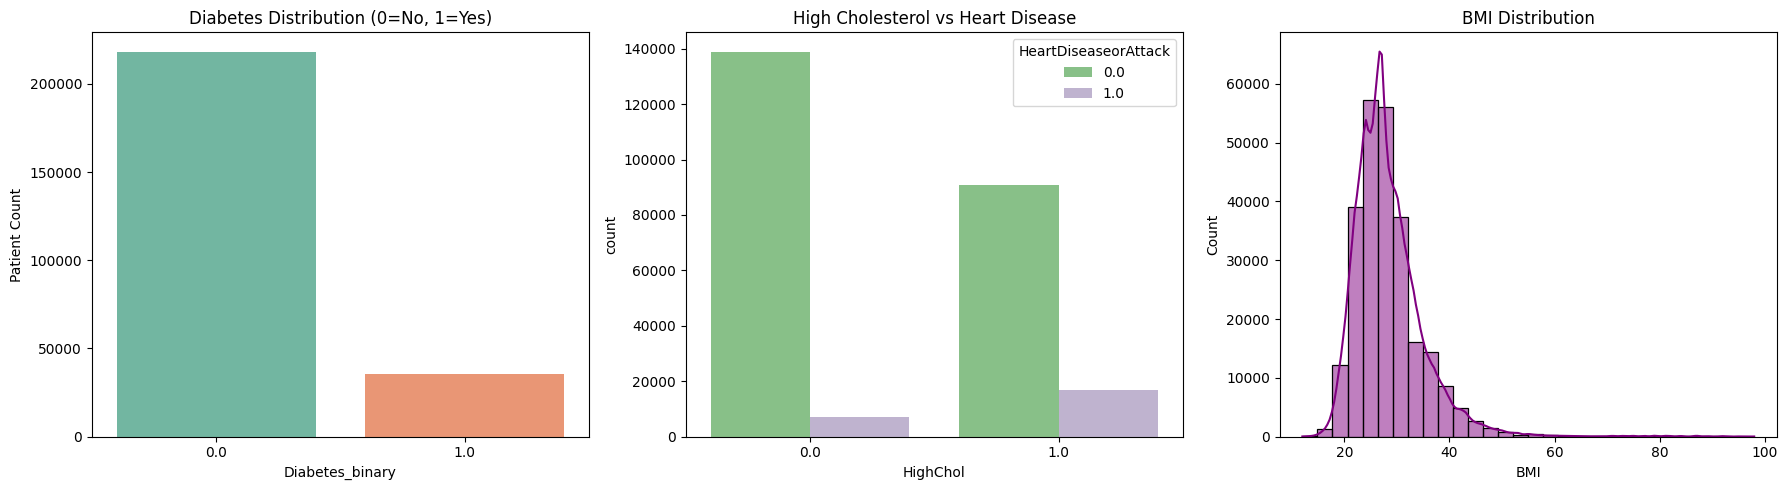

In [10]:
# create 3 Subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Graph 1: Diabetes 
sns.countplot(x='Diabetes_binary', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Diabetes Distribution (0=No, 1=Yes)')
axes[0].set_ylabel('Patient Count')

# Graph 2: High Cholesterol and Heart Disease
sns.countplot(x='HighChol', hue='HeartDiseaseorAttack', data=df, ax=axes[1], palette='Accent')
axes[1].set_title('High Cholesterol vs Heart Disease')

# Graph 3: BMI Distribution
sns.histplot(df['BMI'], bins=30, kde=True, ax=axes[2], color='purple')
axes[2].set_title('BMI Distribution')

plt.tight_layout()
plt.show()

In [11]:
# 80% Training and 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Training Rows: {X_train.shape[0]}")
print(f"Testing Rows: {X_test.shape[0]}")

Training Rows: 202476
Testing Rows: 50620


In [12]:
# 1. Algorithm List
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42),
    'XGBoost (Default)': XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, eval_metric='logloss'),
    'XGBoost (Balanced)': XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, scale_pos_weight=3.5, random_state=42, eval_metric='logloss')
}

# ප්‍රතිඵල එකතු කරගන්න හිස් ලැයිස්තුවක
results = []

# 2. Loop එකක් මගින් හැම Model එකක්ම Train කරලා Metrics බලමු
for name, model in models.items():
    # Model එක පුහුණු කිරීම
    model.fit(X_train, y_train)
    # අනාවැකි ගැනීම
    y_pred = model.predict(X_test)
    
    # Metrics ගණනය කිරීම
    acc = accuracy_score(y_test, y_pred) * 100
    rec = recall_score(y_test, y_pred) * 100
    f1 = f1_score(y_test, y_pred) * 100
    
    # ප්‍රතිඵල එකතු කිරීම
    results.append({
        'Model Name': name,
        'Accuracy (%)': round(acc, 2),
        'Recall (Class 1) (%)': round(rec, 2),
        'F1-Score (%)': round(f1, 2)
    })

# 3. ප්‍රතිඵල ලස්සන DataFrame වගුවක් විදිහට පෙන්වීම
df_results = pd.DataFrame(results)
df_results.sort_values(by='Accuracy (%)', ascending=False)

,Model Name,Accuracy (%),Recall (Class 1) (%),F1-Score (%)
0,Logistic Regression,90.74,13.00,21.16
2,XGBoost (Default),90.73,9.67,16.63
1,Random Forest,90.58,2.83,5.44
3,XGBoost (Balanced),86.44,52.25,42.42


In [13]:
# 1. XGBoost Model එක නිර්මාණය කිරීම
# scale_pos_weight පාවිච්චි කරන්නේ හාර්ට් ඇටෑක් දත්ත අඩු නිසා ඒක balance කරන්නයි
heart_model = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42, eval_metric='logloss')

# 2. Model එක Train කිරීම
heart_model.fit(X_train, y_train)

# 3. Test දත්ත මගින් අනාවැකි ලබා ගැනීම
y_pred = heart_model.predict(X_test)

# 4. Accuracy එක පරීක්ෂා කිරීම
accuracy = accuracy_score(y_test, y_pred)
print(f"🥇 Heart Disease Model Accuracy: {accuracy * 100:.2f}%\n")
print("📋 Detailed Classification Report:\n", classification_report(y_test, y_pred))

🥇 Heart Disease Model Accuracy: 90.74%

📋 Detailed Classification Report:
               precision    recall  f1-score   support

         0.0       0.91      0.99      0.95     45782
         1.0       0.60      0.10      0.16      4838

    accuracy                           0.91     50620
   macro avg       0.75      0.54      0.56     50620
weighted avg       0.88      0.91      0.88     50620



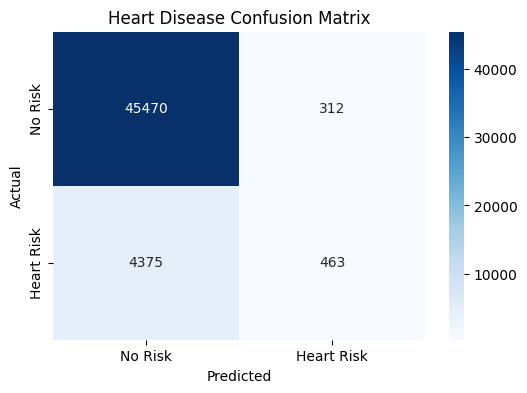

In [14]:
# Confusion Matrix එක ලබා ගැනීම
cm = confusion_matrix(y_test, y_pred)

# ප්‍රස්ථාරය ඇඳීම
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Risk', 'Heart Risk'], yticklabels=['No Risk', 'Heart Risk'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Heart Disease Confusion Matrix')
plt.show()

In [15]:
# හාර්ට් මොඩල් එක සේව් කිරීම
heart_model.save_model('heart_model.json')
print("Heart Model Saved!")

Heart Model Saved!
